In [3]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
sys.path.append('G:/Utilisateurs/anas.skalli/Desktop/ONN_experiments/Simulation/Nonlinear_oscillator_net/nonlinear_oscillator_network/Utils')

from NN_utils import *
import torch
import torch.nn as nn
from torchvision import datasets, transforms
#from torchsummary import summary
import time
from types import SimpleNamespace
import pickle
import gc
from torch.utils.data import DataLoader


In [4]:
# --- Parameters ---
RNN_params = {
    "N_in": 784,
    "N_out": 10,
    "N_neurons": 50,
    "N_layers": 3,
    "time_steady_state": 1000
}


model = Oscillator_RNN_dyn(params=RNN_params)
model.init_esn_weights(reservoir = True)
# Set model to eval mode and CPU (or use GPU if preferred)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.max_steps=100
model.alpha = 3

# --- Load one FashionMNIST sample ---
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
# Create DataLoader for a batch of 100 samples
loader = DataLoader(dataset, batch_size=1000, shuffle=False)

# Get one batch
img, label = next(iter(loader))
# Flatten and prepare repeated input
x = img.to(device)  # (1, 784)
T = RNN_params["time_steady_state"]

#model = torch.compile(model)
# --- Forward Pass ---
start_time = time.time()
with torch.no_grad():
    y_pred = model(x,eps_int=1e-4,dt=0.1,save_activations=True)
end_time = time.time()

print(f' Forward pass time {end_time - start_time}')

 Forward pass time 0.6985974311828613


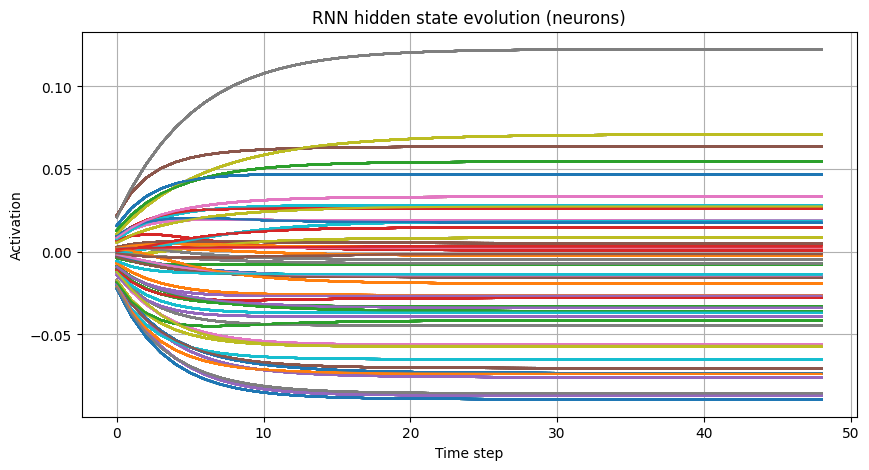

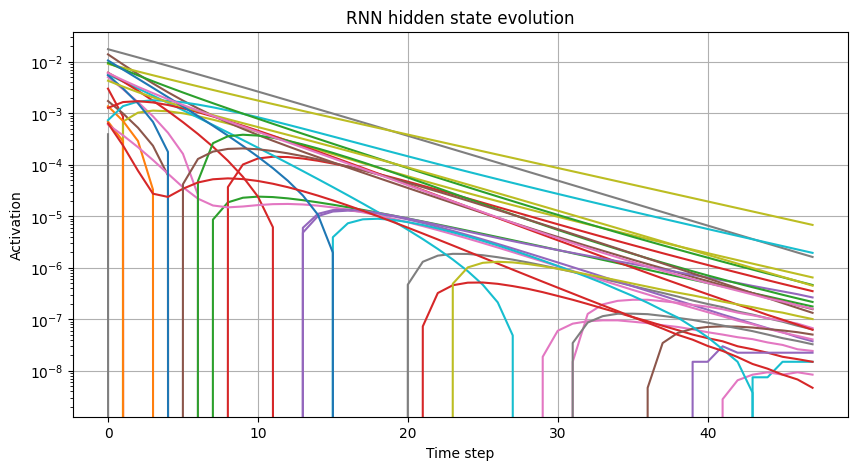

In [ ]:
layer = 'layer1'
# --- Plot Hidden State Over Time (first neuron for example) ---
rnn_out = torch.stack(model.activations[layer]).squeeze().numpy()  # shape: (T, hidden_size)
plt.figure(figsize=(10, 5))
for i in range(RNN_params["N_neurons"]):  # plot neurons
    plt.plot(rnn_out[:,50,:], label=f"Neuron {i}")
plt.xlabel("Time step")
plt.ylabel("Activation")
plt.title("RNN hidden state evolution (neurons)")
#plt.legend()
plt.grid(True)
plt.show()

dummy = rnn_out[:,50,:]
plt.figure(figsize=(10, 5))
for i in range(RNN_params["N_neurons"]):  # plot first 5 neurons
    plt.semilogy(np.diff(dummy[:, i],axis =0), label=f"Neuron {i}")
plt.xlabel("Time step")
plt.ylabel("Activation")
plt.title("RNN hidden state evolution (pairwise difference between successive timse steps)")
#plt.legend()
plt.grid(True)
plt.show()